In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from numba_stats import norm
from numba_stats import uniform

In [2]:
rng = np.random.default_rng(2021)

In [3]:
def target(x):
    return np.exp(-(x**2)) * (2 + np.sin(5 * x) + np.sin(2 * x))

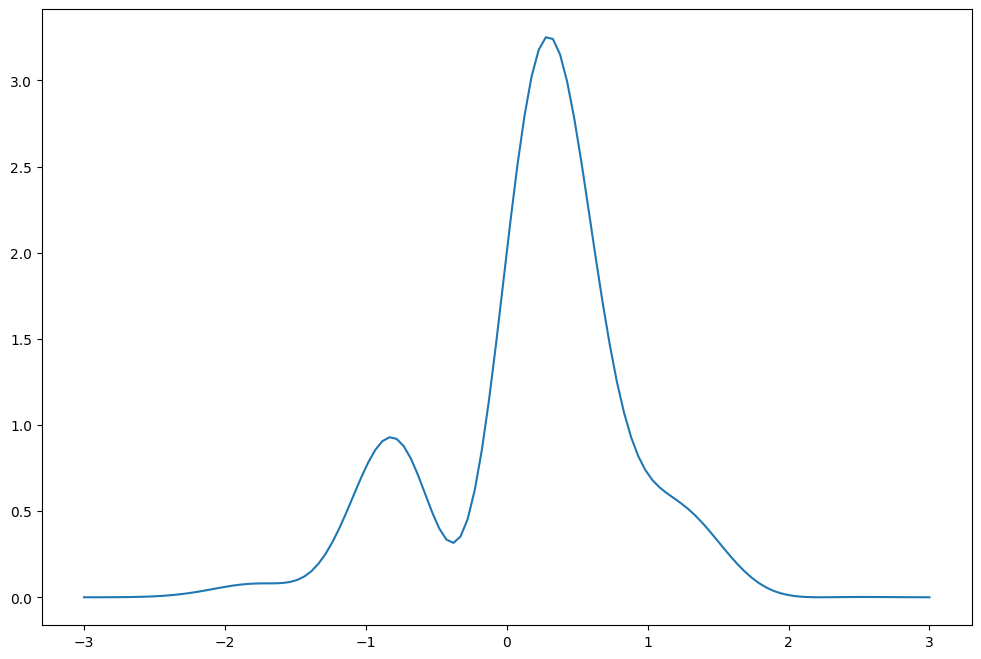

In [4]:
x = np.linspace(-3, 3, 120)
y = target(x)
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(x, y)

In [5]:
def metropolis_iteration(x, prop, u):

    proposed_prob = x + prop
    accept_prob = min(1.0, target(proposed_prob) / target(x))

    value = x

    if u <= accept_prob:
        value = proposed_prob

    return value

In [6]:
def metropolis_sampler(initial_value, n=1000, sigma=1.0, burnin=0, lag=1):

    trace = np.zeros(n)

    current_state = initial_value

    size = burnin + n * lag
    uni = uniform.rvs(a=0, w=1, size=size, random_state=1)
    props = norm.rvs(loc=0, scale=sigma, size=size, random_state=1)

    for i in range(burnin):
        value = metropolis_iteration(current_state, props[i], uni[i])
        current_state = value

    for i in range(n):
        for j in range(lag):
            index = burnin + i * lag + j
            value = metropolis_iteration(current_state, props[index], uni[index])
            current_state = value

        trace[i] = value

    return trace

In [7]:
result = metropolis_sampler(initial_value=0, n=10000, lag=10)

In [8]:
result

array([ 0.4069046 ,  0.57096632, -0.75558142, ...,  0.61659442,
        0.5540293 ,  0.5540293 ])

In [9]:
sigmas = [1, 0.025, 50]
n = 10000
traces = []

In [10]:
bins = np.linspace(-3, 3, 120)
p = target(bins)
expected = n * p / sum(p)

In [11]:
for i in range(len(sigmas)):
    traces.append(metropolis_sampler(initial_value=-1, n=n, sigma=sigmas[i]))

In [14]:
traces[0].shape

(10000,)

In [17]:
foo = np.vstack((np.arange(0,n), traces[0]))
foo.shape

(2, 10000)

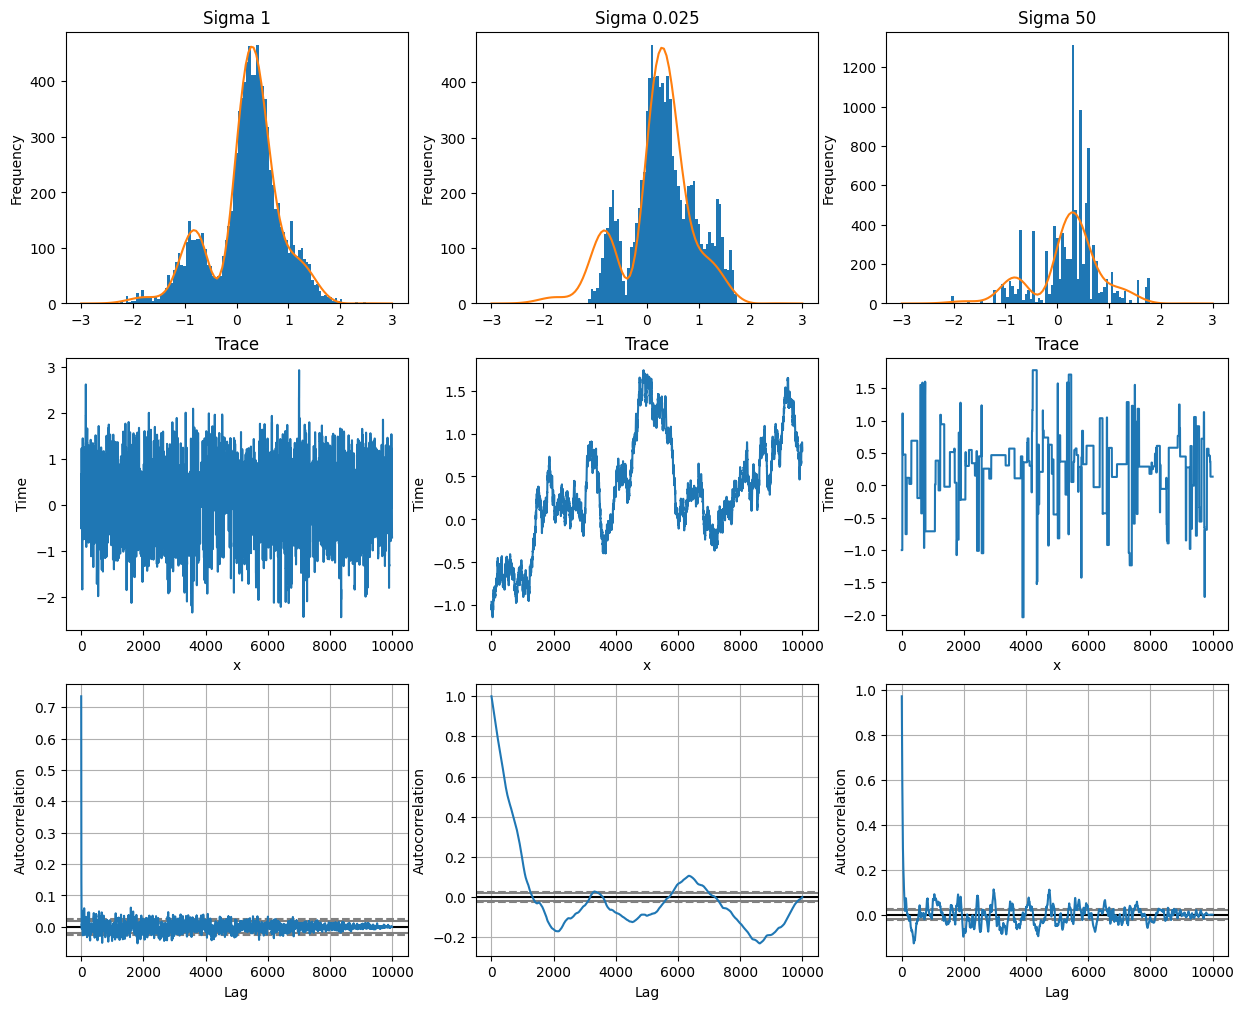

In [27]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
for j in range(3):
    axs[0, j].hist(traces[j], bins=bins)
    axs[0, j].set(title="Sigma " + str(sigmas[j]), ylabel="Frequency")
    axs[0, j].plot(bins, expected)
    axs[1, j].plot(traces[j], np.arange(0, n))
    axs[1, j].set(title="Trace", ylabel="Time", xlabel="x")
    autocorrelation_plot(traces[j], axs[2, j])

In [110]:
traces = []
n = 1000
expected = n * p / sum(p)
for i in range(3):
    traces.append(metropolis_sampler(initial_value=-3, n=n, sigma=0.1))

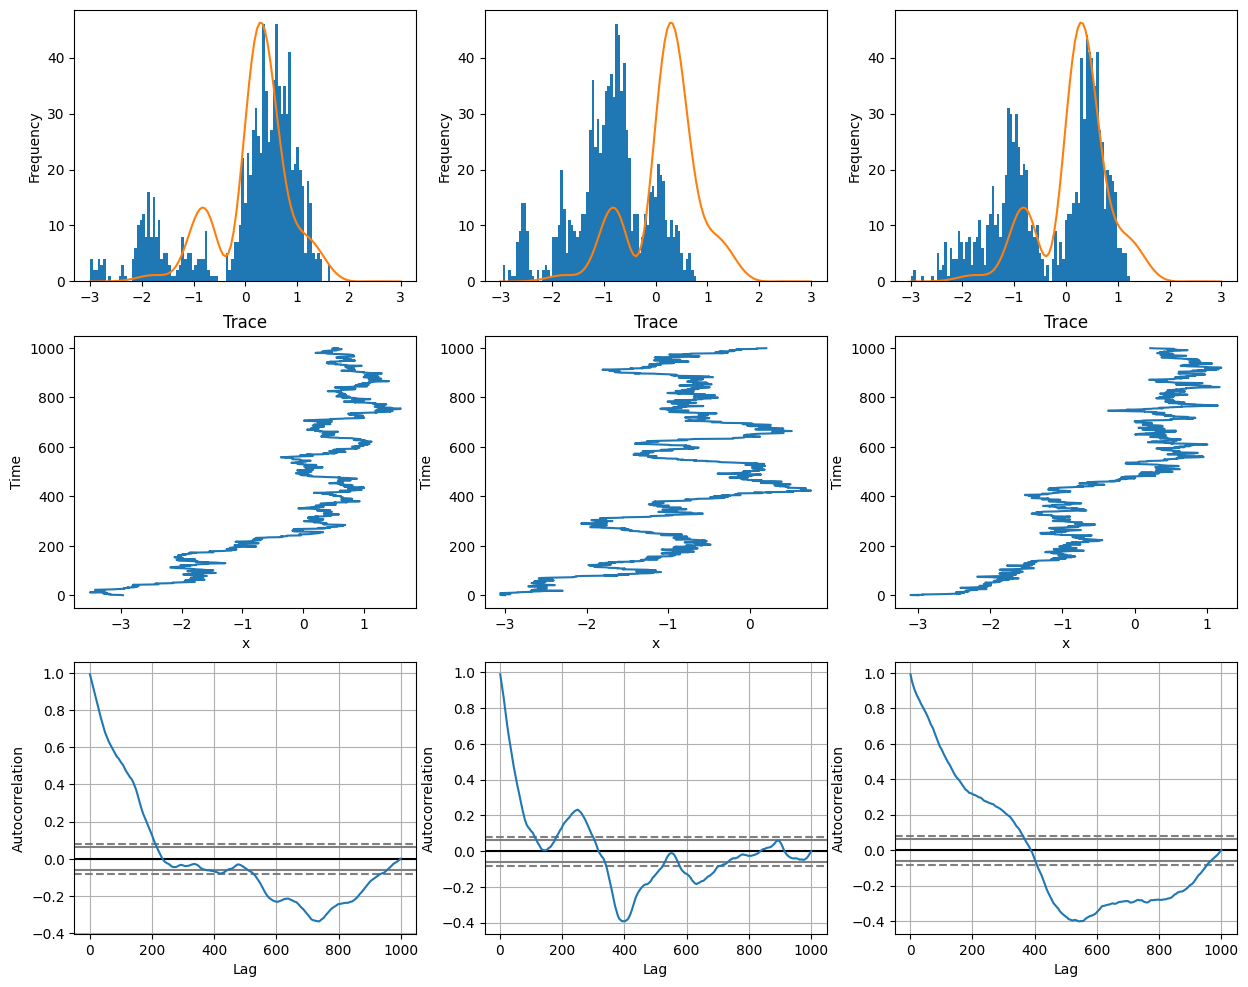

In [111]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
for j in range(3):
    axs[0, j].hist(traces[j], bins=bins)
    axs[0, j].plot(bins, expected)
    axs[0, j].set(ylabel="Frequency")
    axs[1, j].plot(traces[j], np.arange(0, n))
    axs[1, j].set(title="Trace", ylabel="Time", xlabel="x")
    autocorrelation_plot(traces[j], axs[2, j])

In [112]:
traces = []
n = 1000
expected = n * p / sum(p)
for i in range(3):
    traces.append(metropolis_sampler(initial_value=-3, burnin=200, n=n, sigma=0.1))

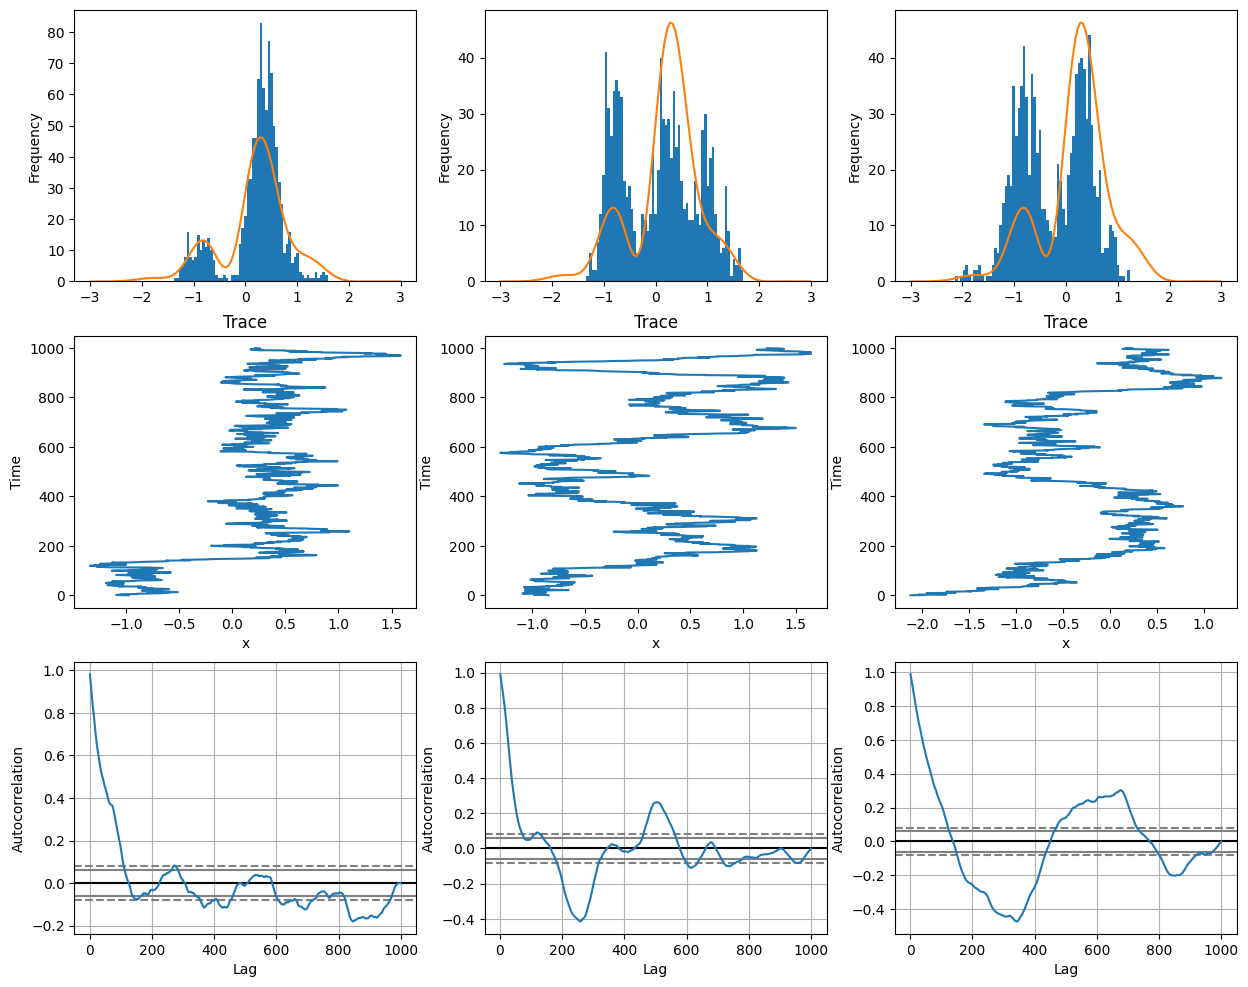

In [113]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
for j in range(3):
    axs[0, j].hist(traces[j], bins=bins)
    axs[0, j].plot(bins, expected)
    axs[0, j].set(ylabel="Frequency")
    axs[1, j].plot(traces[j], np.arange(0, n))
    axs[1, j].set(title="Trace", ylabel="Time", xlabel="x")
    autocorrelation_plot(traces[j], axs[2, j])

In [114]:
traces = []
n = 1000
expected = n * p / sum(p)
lag = [1, 10, 100]
for i in range(3):
    traces.append(metropolis_sampler(initial_value=0, lag=lag[i], n=n, sigma=50))

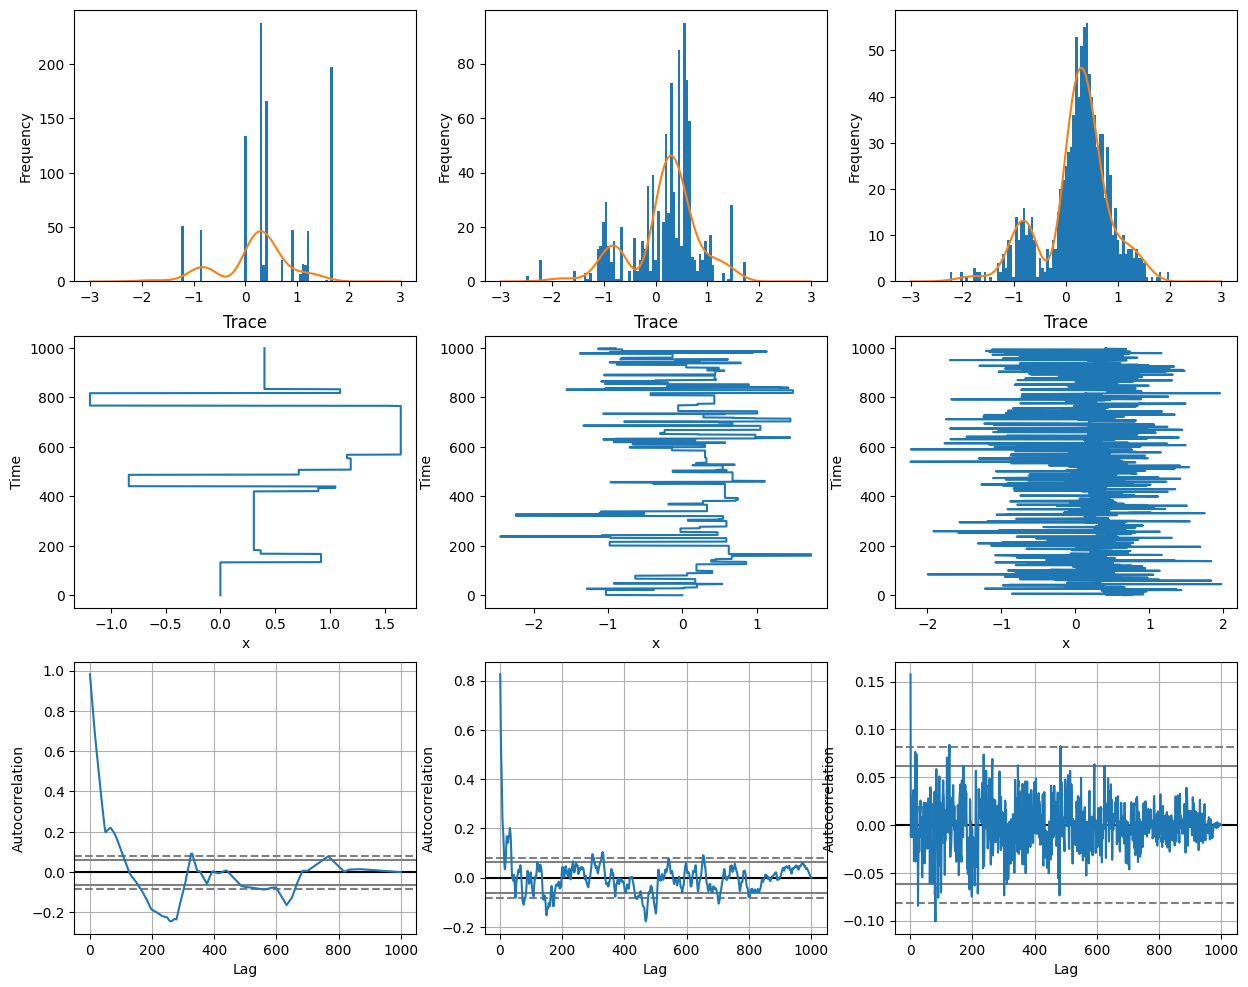

In [115]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
for j in range(3):
    axs[0, j].hist(traces[j], bins=bins)
    axs[0, j].plot(bins, expected)
    axs[0, j].set(ylabel="Frequency")
    axs[1, j].plot(traces[j], np.arange(0, n))
    axs[1, j].set(title="Trace", ylabel="Time", xlabel="x")
    autocorrelation_plot(traces[j], axs[2, j])

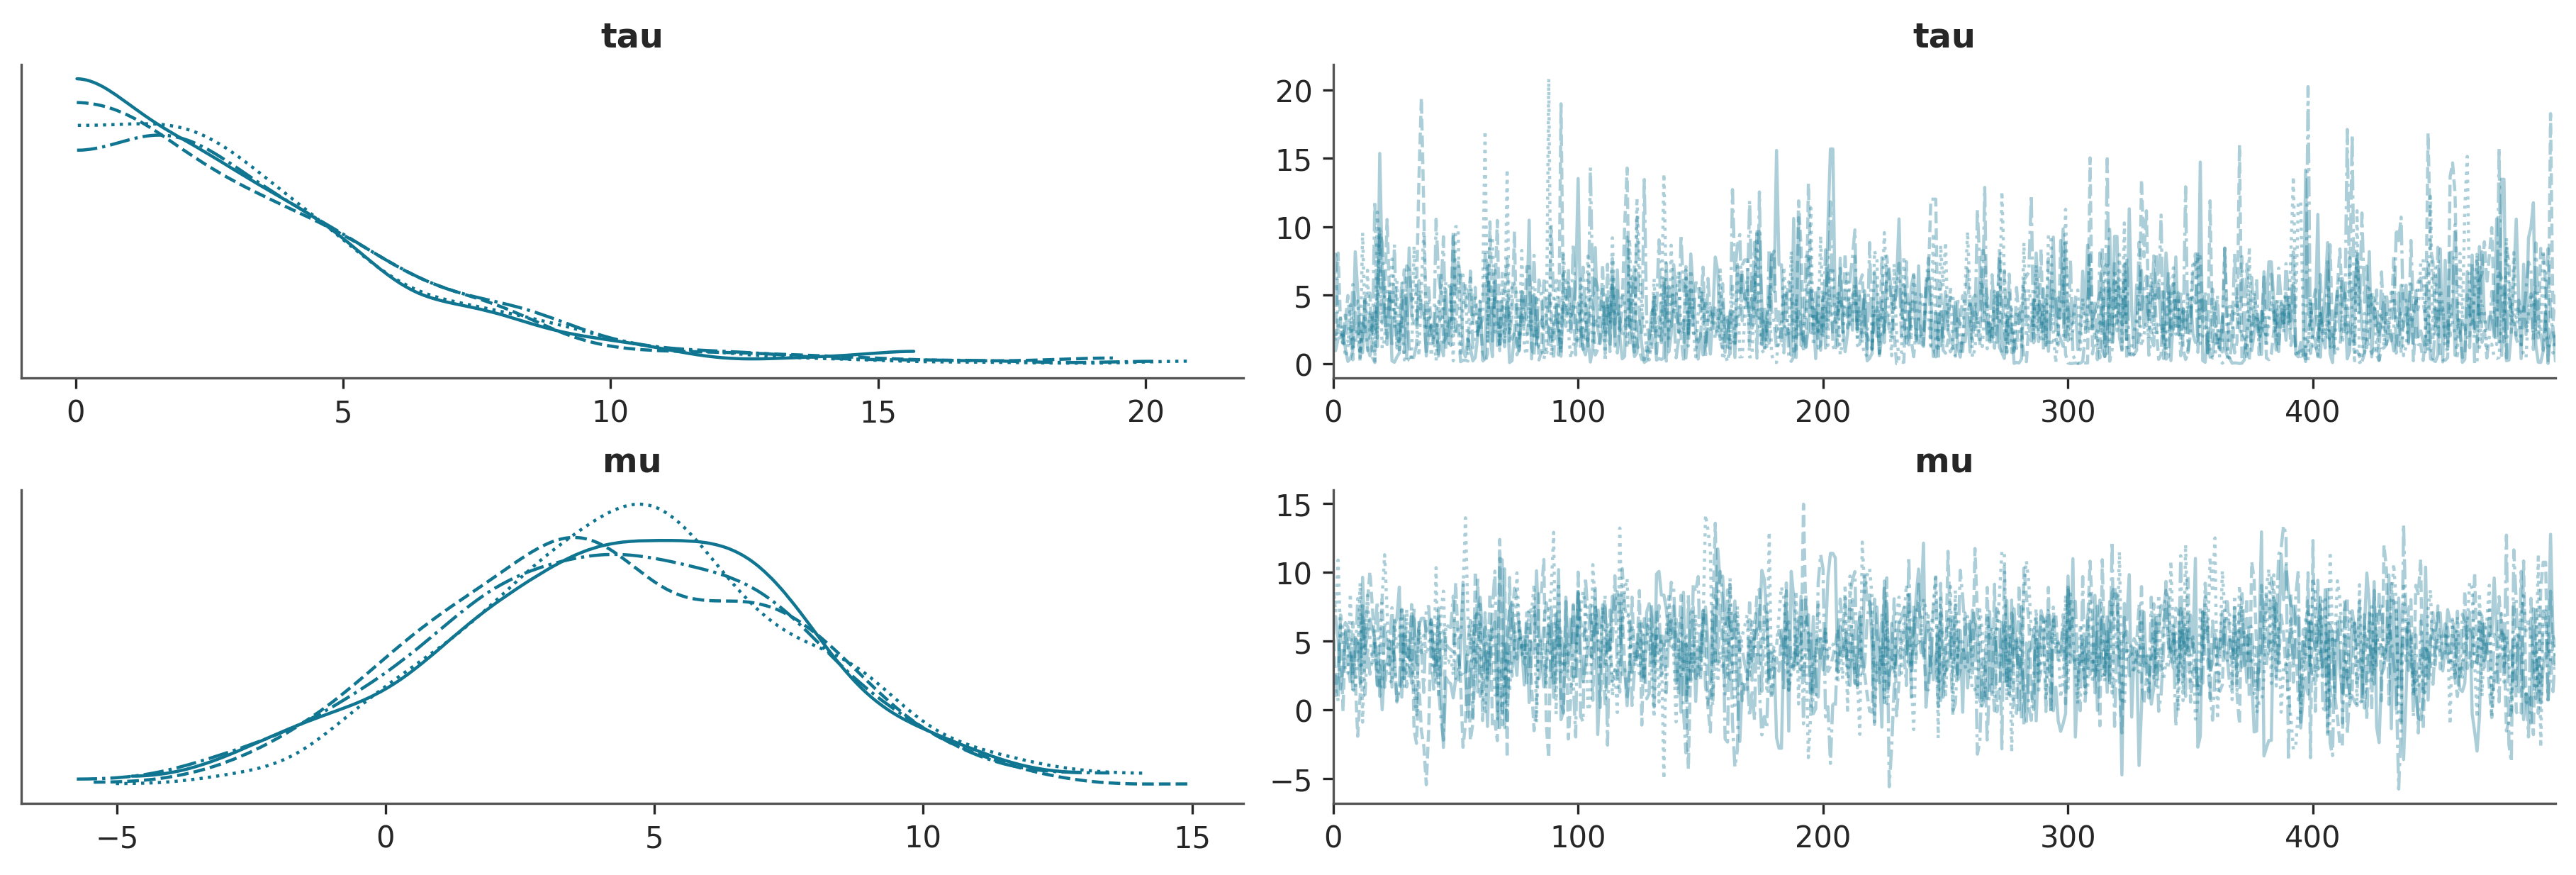

In [18]:
import matplotlib.pyplot as plt

import arviz as az

az.style.use("arviz-doc")

data = az.load_arviz_data("non_centered_eight")


In [19]:
data

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

In [ ]:
az.plot_trace(data, var_names=("tau", "mu"))

plt.show()

In [39]:
traces

[array([ 0.62434536,  0.01258895, -0.5155828 , ..., -0.65062865,
        -0.71332488, -0.71332488]),
 array([-0.95939137, -0.97468528, -0.98788957, ...,  0.84092913,
         0.83936172,  0.80341497]),
 array([-1.        , -1.        , -1.        , ...,  0.13505679,
         0.13505679,  0.13505679])]

In [37]:


foo = np.vstack((np.arange(0,2), traces))
foo.shape

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 10000

In [38]:
import xarray as xr

In [48]:
bar = xr.DataArray(np.array([traces[0]]), dims=["chain", "draw"])

In [49]:
bar

<xarray.DataArray (chain: 1, draw: 10000)> Size: 80kB
array([[ 0.62434536,  0.01258895, -0.5155828 , ..., -0.65062865,
        -0.71332488, -0.71332488]])
Dimensions without coordinates: chain, draw

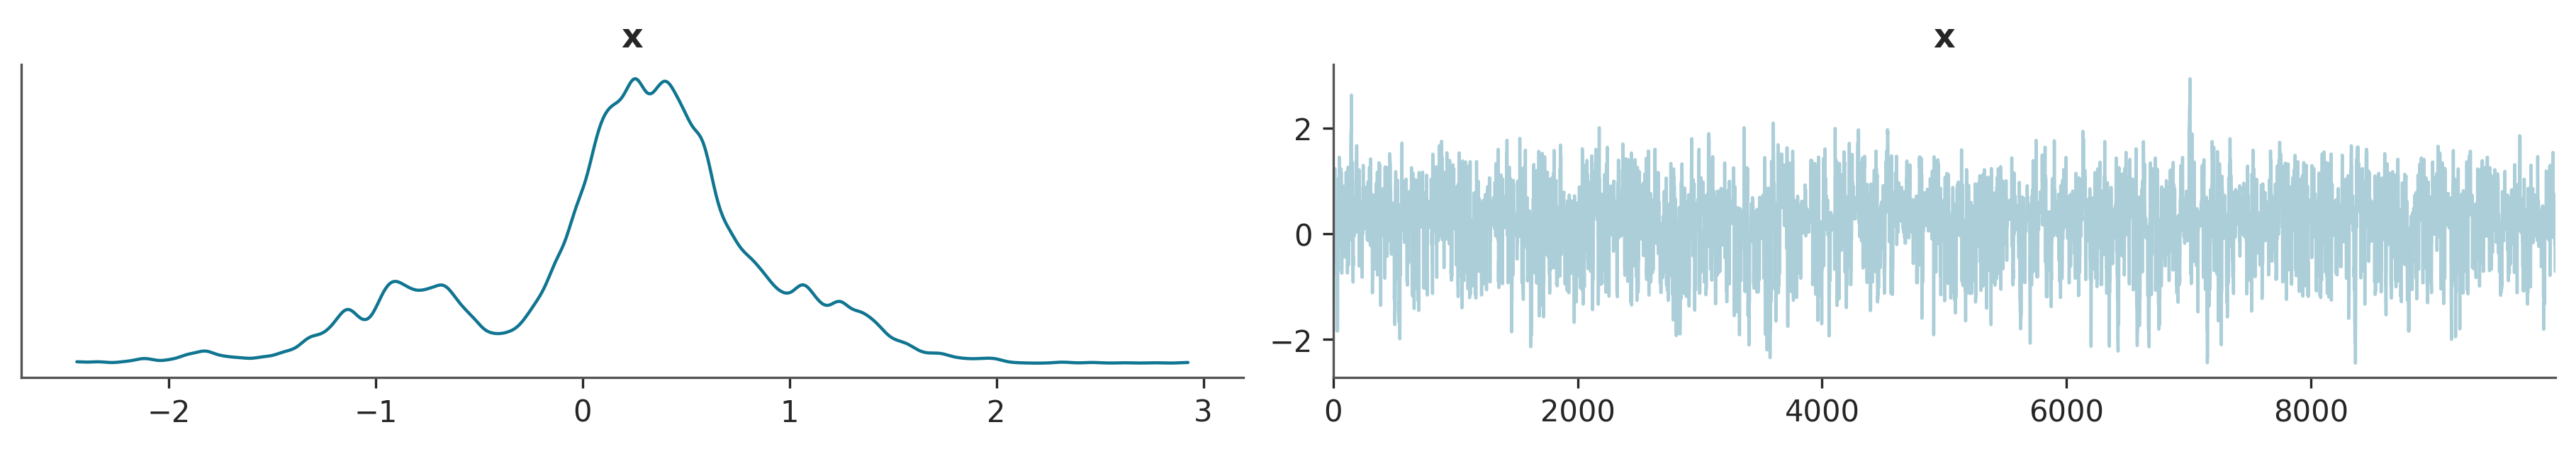

In [92]:
ax4=az.plot_trace(bar)


In [102]:
fig = ax4[0][0].get_figure()

In [104]:
ax5=fig.add_subplot()

In [94]:
type(ax4[0][0])

matplotlib.axes._axes.Axes

In [105]:
ax5.plot(bins, expected)

In [99]:
fig = ax4[0][1].get_figure()

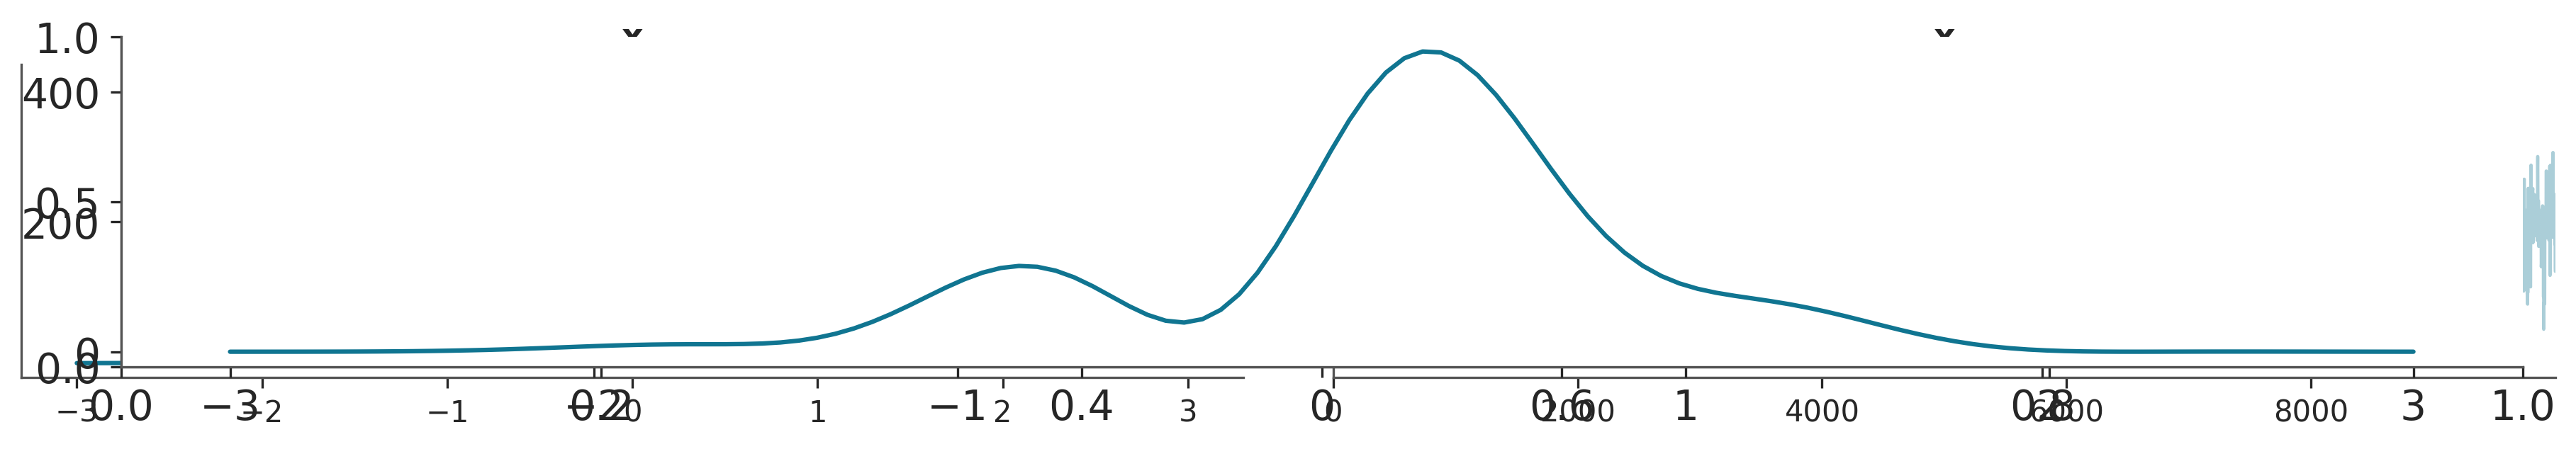

In [106]:
fig

<Axes: title={'center': 'x\n0'}>

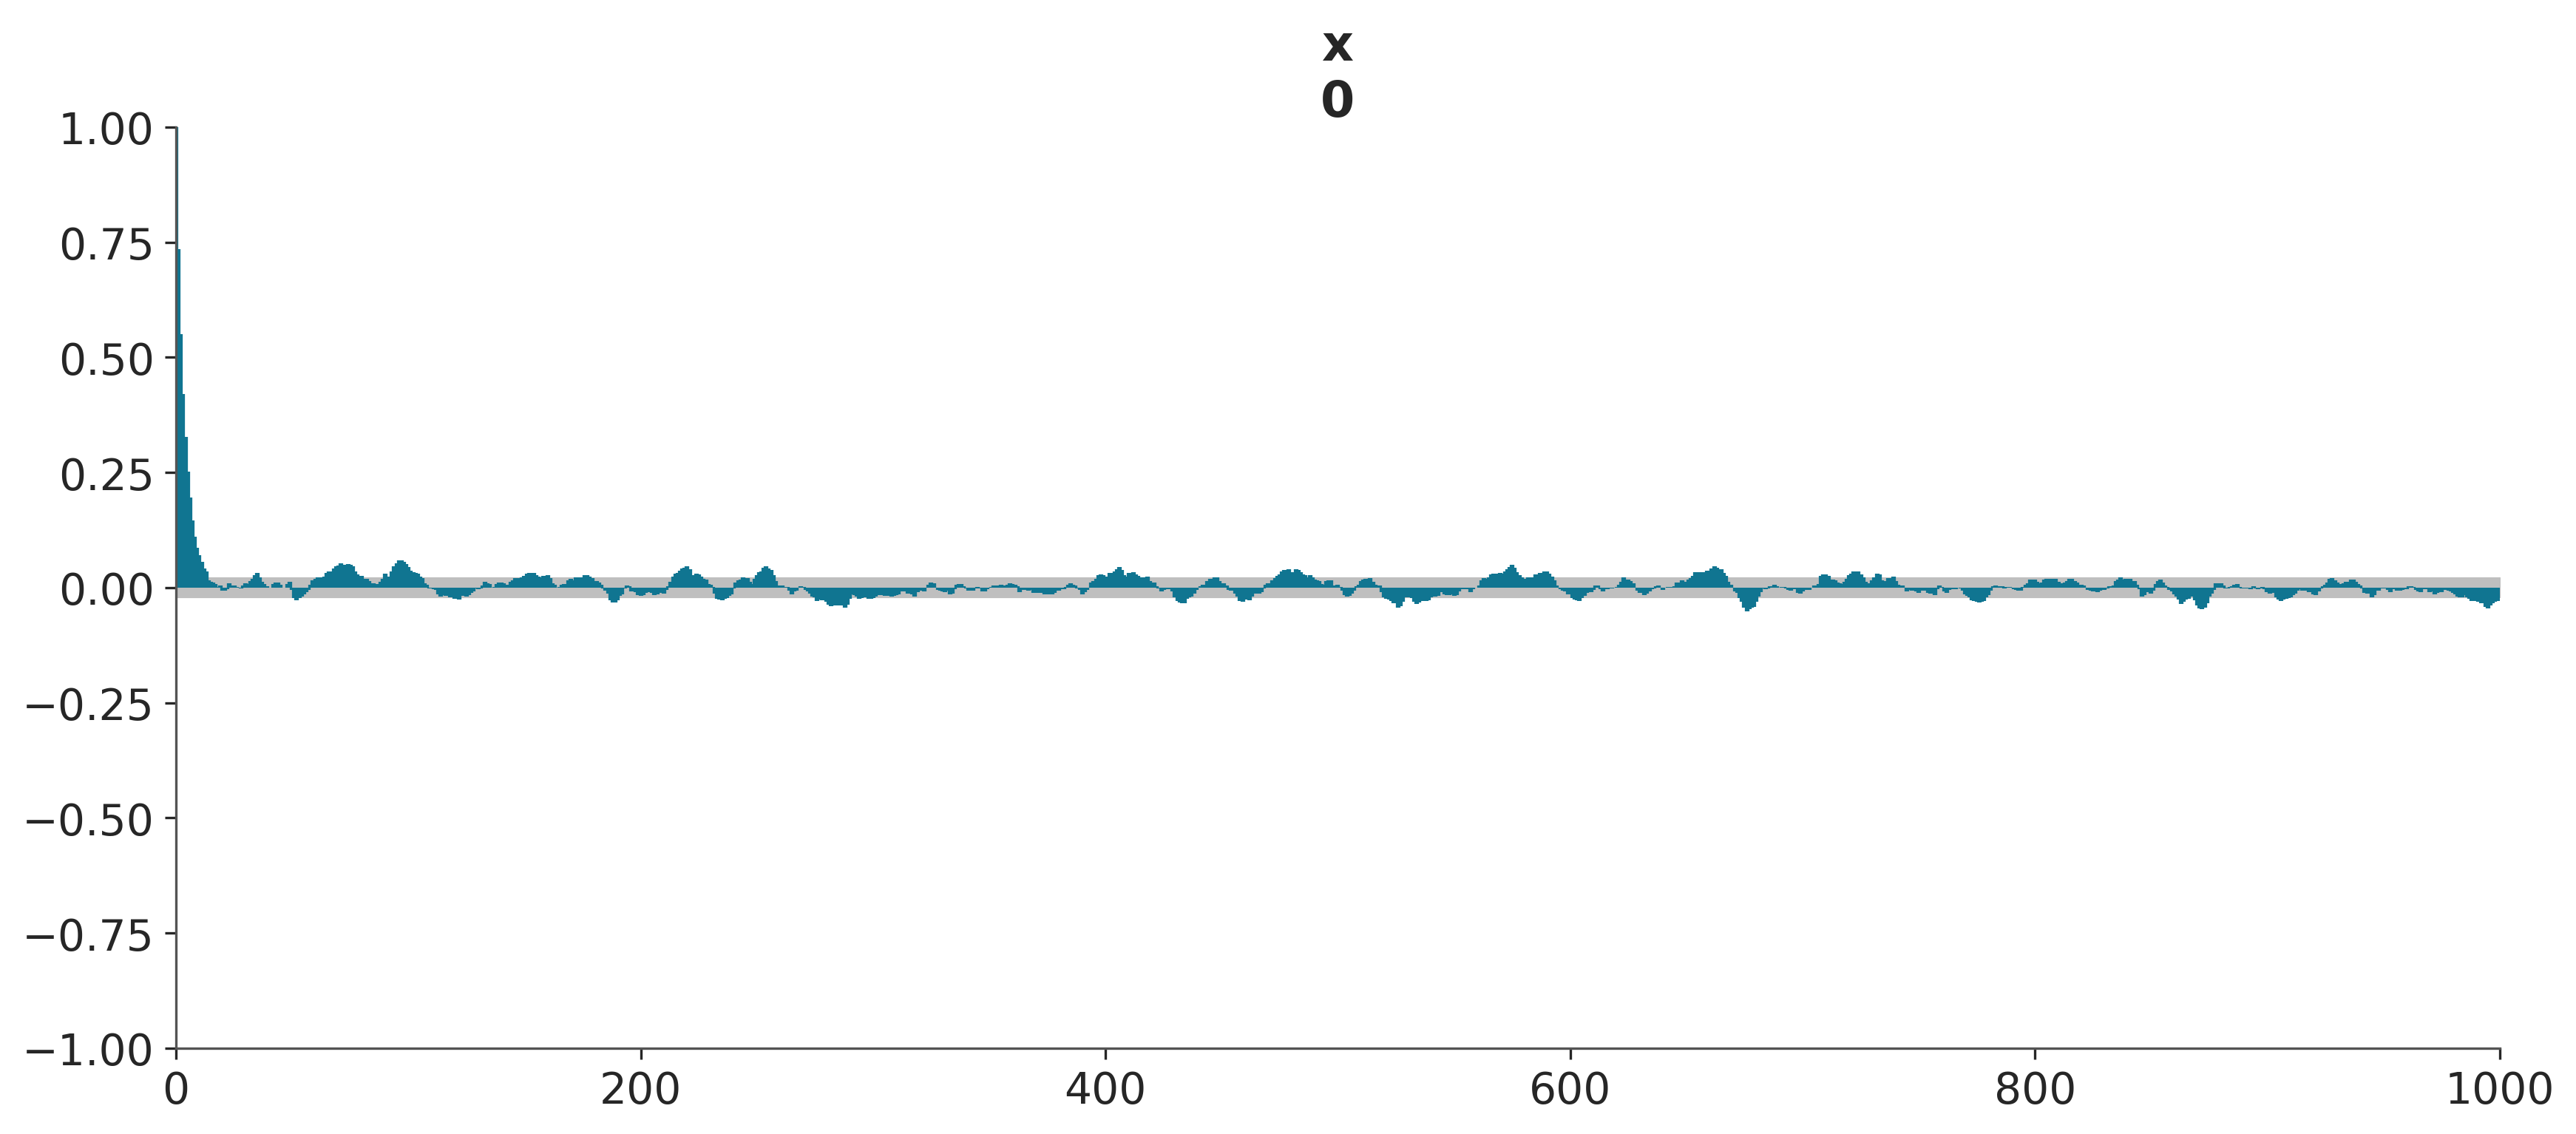

In [98]:
az.plot_autocorr(bar, max_lag=1000)